In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor

import joblib
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "rice_market_1000.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (1000, 9)


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Rice,42.3,16.8,0.0,2098,0,1609
1,2023-01-02,Delhi,Rice,42.8,16.7,1.1,2160,0,1653
2,2023-01-03,Delhi,Rice,42.5,16.5,0.6,2185,0,1679
3,2023-01-04,Delhi,Rice,43.0,16.8,0.0,2231,0,1716
4,2023-01-05,Delhi,Rice,43.4,16.9,0.8,2278,0,1758



Columns:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of Rows: 1000
Number of Columns: 9

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                1000 non-null   str    
 1   location            1000 non-null   str    
 2   crop                1000 non-null   str    
 3   price_per_kg        1000 non-null   float64
 4   temperature_c       1000 non-null   float64
 5   rainfall_mm         1000 non-null   float64
 6   market_arrivals_kg  1000 non-null   int64  
 7   festival_flag       1000 non-null   int64  
 8   demand_kg           1000 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 90.8 KB


In [4]:
print(df.dtypes)

date                      str
location                  str
crop                      str
price_per_kg          float64
temperature_c         float64
rainfall_mm           float64
market_arrivals_kg      int64
festival_flag           int64
demand_kg               int64
dtype: object


In [5]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
date                  0
location              0
crop                  0
price_per_kg          0
temperature_c         0
rainfall_mm           0
market_arrivals_kg    0
festival_flag         0
demand_kg             0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [7]:
print("Unique Locations:")
print(df["location"].unique())

print("\nNumber of Locations:")
print(df["location"].nunique())

print("\nUnique Crops:")
print(df["crop"].unique())

print("\nNumber of Crops:")
print(df["crop"].nunique())

Unique Locations:
<ArrowStringArray>
[    'Delhi',     'Noida', 'Ghaziabad',  'Gurugram', 'Faridabad',   'Sonipat',
   'Panipat',    'Meerut',    'Rohtak']
Length: 9, dtype: str

Number of Locations:
9

Unique Crops:
<ArrowStringArray>
['Rice']
Length: 1, dtype: str

Number of Crops:
1


In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Minimum Date:", df["date"].min())
print("Maximum Date:", df["date"].max())

Minimum Date: 2023-01-01 00:00:00
Maximum Date: 2025-09-26 00:00:00


In [9]:
display(df.describe(include="all"))

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
count,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
unique,NaN,9,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Delhi,Rice,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,120,1000,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-05-14 12:00:00,NaN,NaN,45.677300,23.802800,0.165700,1234.592000,0.10000,960.058000
min,2023-01-01 00:00:00,NaN,NaN,40.000000,16.200000,0.000000,675.000000,0.00000,520.000000
25%,2023-09-07 18:00:00,NaN,NaN,43.300000,18.300000,0.000000,959.000000,0.00000,740.000000
50%,2024-05-14 12:00:00,NaN,NaN,45.900000,24.400000,0.000000,1099.000000,0.00000,851.500000
75%,2025-01-19 06:00:00,NaN,NaN,47.600000,28.400000,0.000000,1271.000000,0.00000,1001.000000
max,2025-09-26 00:00:00,NaN,NaN,53.100000,31.100000,1.200000,2706.000000,1.00000,2261.000000


In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [11]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print(df["date"].dtype)

print("Invalid Dates:", df["date"].isnull().sum())

datetime64[us]
Invalid Dates: 0


In [12]:
before_rows = len(df)

df = df.dropna(subset=["date"])

after_rows = len(df)

print("Rows Before:", before_rows)
print("Rows After:", after_rows)

Rows Before: 1000
Rows After: 1000


In [13]:
df = df.sort_values(
    by=["location", "crop", "date"]
).reset_index(drop=True)

display(df.head())

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Rice,42.3,16.8,0.0,2098,0,1609
1,2023-01-02,Delhi,Rice,42.8,16.7,1.1,2160,0,1653
2,2023-01-03,Delhi,Rice,42.5,16.5,0.6,2185,0,1679
3,2023-01-04,Delhi,Rice,43.0,16.8,0.0,2231,0,1716
4,2023-01-05,Delhi,Rice,43.4,16.9,0.8,2278,0,1758


In [14]:
before_rows = len(df)

df = df.drop_duplicates()

after_rows = len(df)

print("Duplicates Removed:", before_rows - after_rows)
print("Remaining Rows:", after_rows)

Duplicates Removed: 0
Remaining Rows: 1000


In [15]:
categorical_columns = [
    "location",
    "crop"
]

for column in categorical_columns:
    
    if df[column].isnull().sum() > 0:
        
        mode_value = df[column].mode()[0]
        
        df[column] = df[column].fillna(mode_value)

print("Categorical missing values handled.")

Categorical missing values handled.


In [16]:
numerical_columns = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag"
]

for column in numerical_columns:
    
    df[column] = (
        df.groupby(
            ["location", "crop"]
        )[column]
        .transform(
            lambda x: x.interpolate(
                limit_direction="both"
            )
        )
    )

    df[column] = df[column].fillna(
        df[column].median()
    )

print("Numerical missing values handled.")

Numerical missing values handled.


In [17]:
before_rows = len(df)

df = df.dropna(
    subset=["demand_kg"]
)

after_rows = len(df)

print("Rows Removed Due To Missing Demand:", before_rows - after_rows)

Rows Removed Due To Missing Demand: 0


In [18]:
print("Negative Price:")
print((df["price_per_kg"] < 0).sum())

print("\nNegative Rainfall:")
print((df["rainfall_mm"] < 0).sum())

print("\nNegative Market Arrivals:")
print((df["market_arrivals_kg"] < 0).sum())

print("\nNegative Demand:")
print((df["demand_kg"] < 0).sum())

Negative Price:
0

Negative Rainfall:
0

Negative Market Arrivals:
0

Negative Demand:
0


In [19]:
before_rows = len(df)

df = df[
    (df["price_per_kg"] >= 0) &
    (df["rainfall_mm"] >= 0) &
    (df["market_arrivals_kg"] >= 0) &
    (df["demand_kg"] >= 0)
].copy()

after_rows = len(df)

print("Invalid Rows Removed:", before_rows - after_rows)
print("Remaining Rows:", after_rows)

Invalid Rows Removed: 0
Remaining Rows: 1000


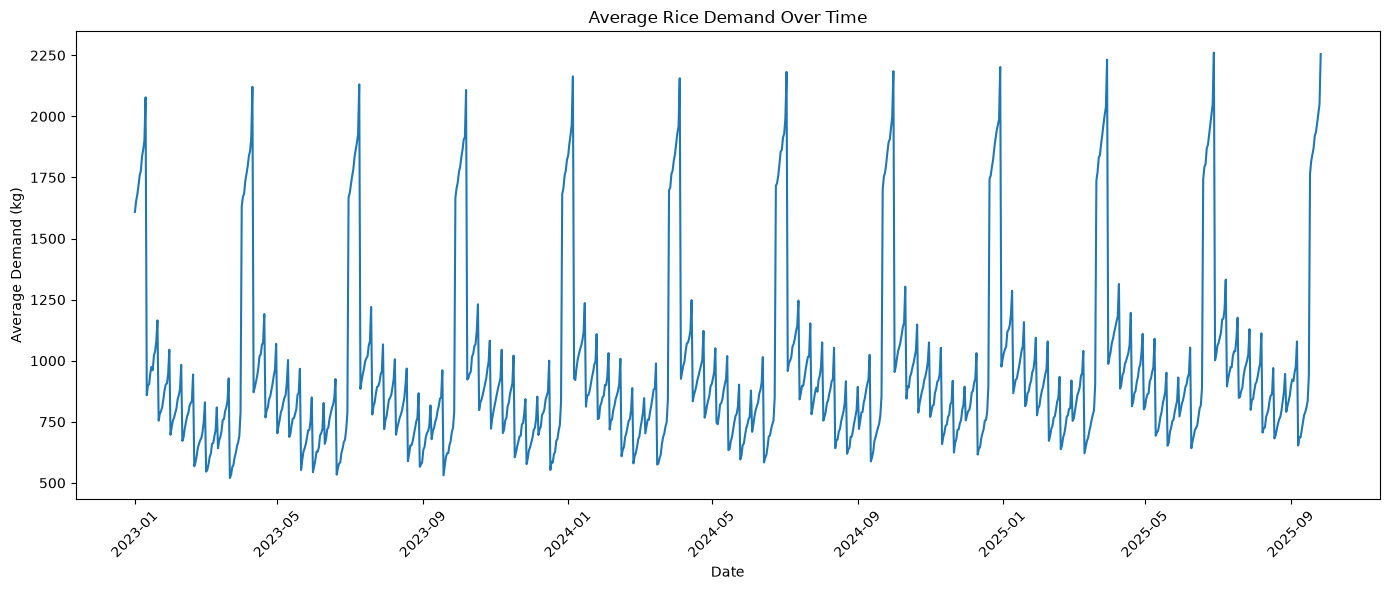

In [20]:
plt.figure(figsize=(14, 6))

daily_demand = (
    df.groupby("date")["demand_kg"]
    .mean()
    .reset_index()
)

plt.plot(
    daily_demand["date"],
    daily_demand["demand_kg"]
)

plt.title("Average Rice Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Demand (kg)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

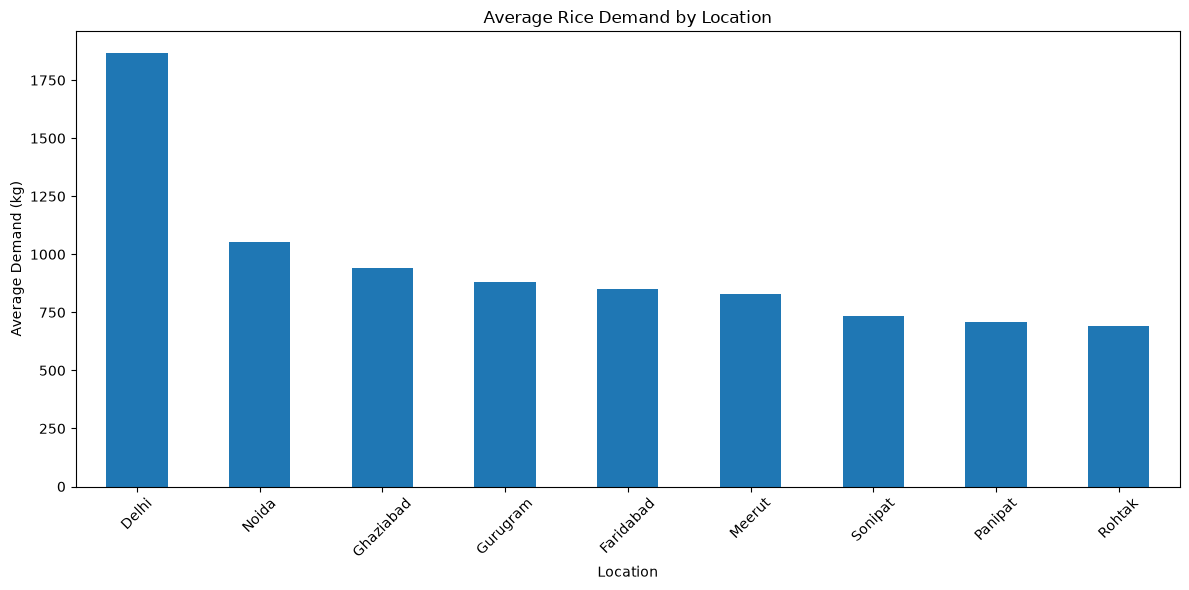

In [21]:
location_demand = (
    df.groupby("location")["demand_kg"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(12, 6))

location_demand.plot(
    kind="bar"
)

plt.title("Average Rice Demand by Location")

plt.xlabel("Location")

plt.ylabel("Average Demand (kg)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

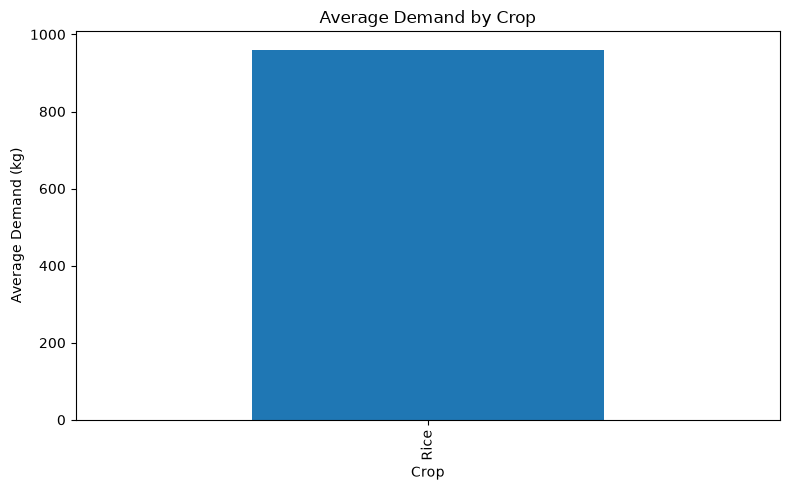

In [22]:
crop_demand = (
    df.groupby("crop")["demand_kg"]
    .mean()
)

plt.figure(figsize=(8, 5))

crop_demand.plot(
    kind="bar"
)

plt.title("Average Demand by Crop")

plt.xlabel("Crop")

plt.ylabel("Average Demand (kg)")

plt.tight_layout()

plt.show()

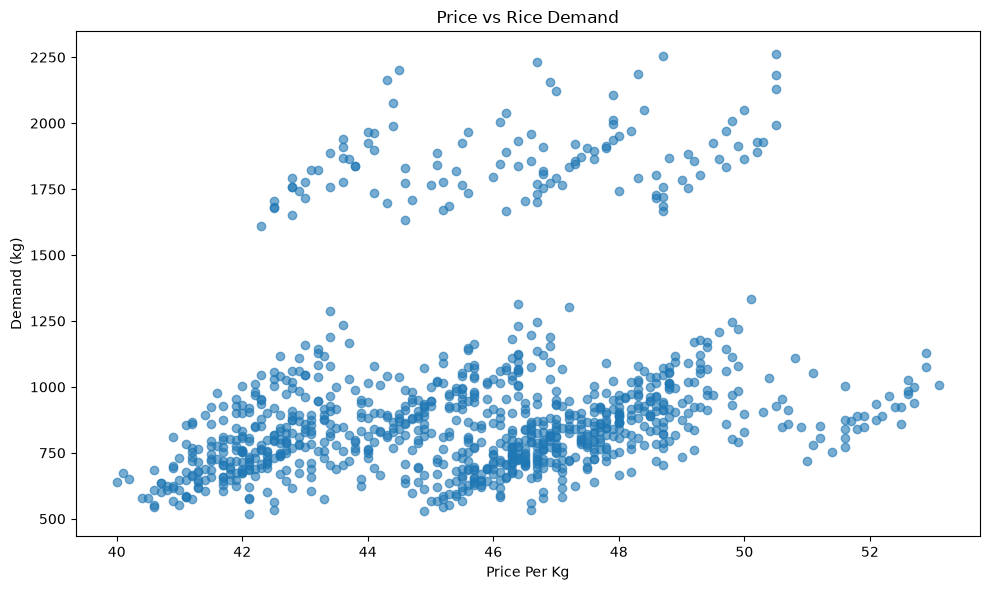

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["price_per_kg"],
    df["demand_kg"],
    alpha=0.6
)

plt.title("Price vs Rice Demand")

plt.xlabel("Price Per Kg")

plt.ylabel("Demand (kg)")

plt.tight_layout()

plt.show()

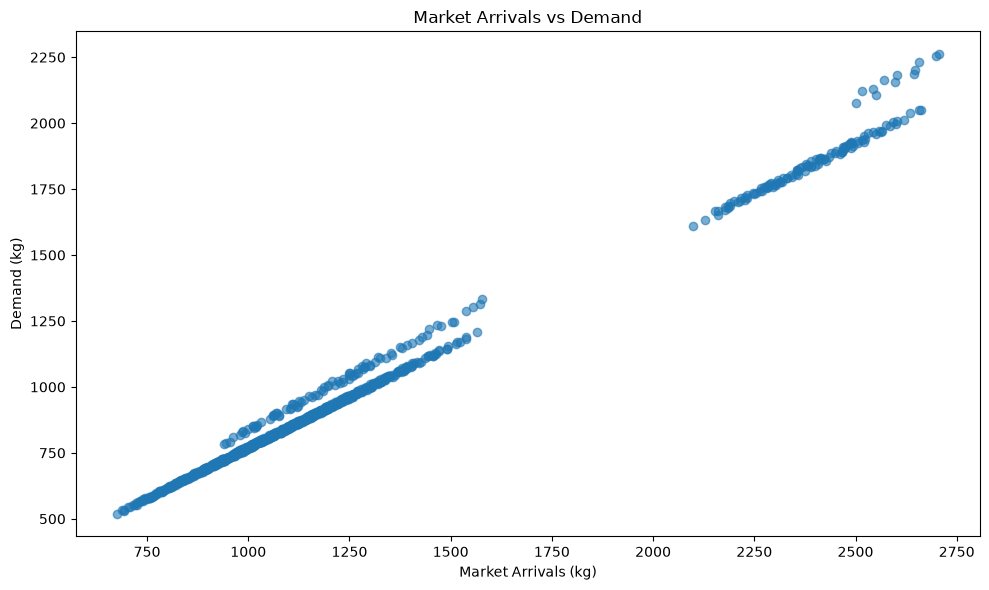

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["market_arrivals_kg"],
    df["demand_kg"],
    alpha=0.6
)

plt.title("Market Arrivals vs Demand")

plt.xlabel("Market Arrivals (kg)")

plt.ylabel("Demand (kg)")

plt.tight_layout()

plt.show()

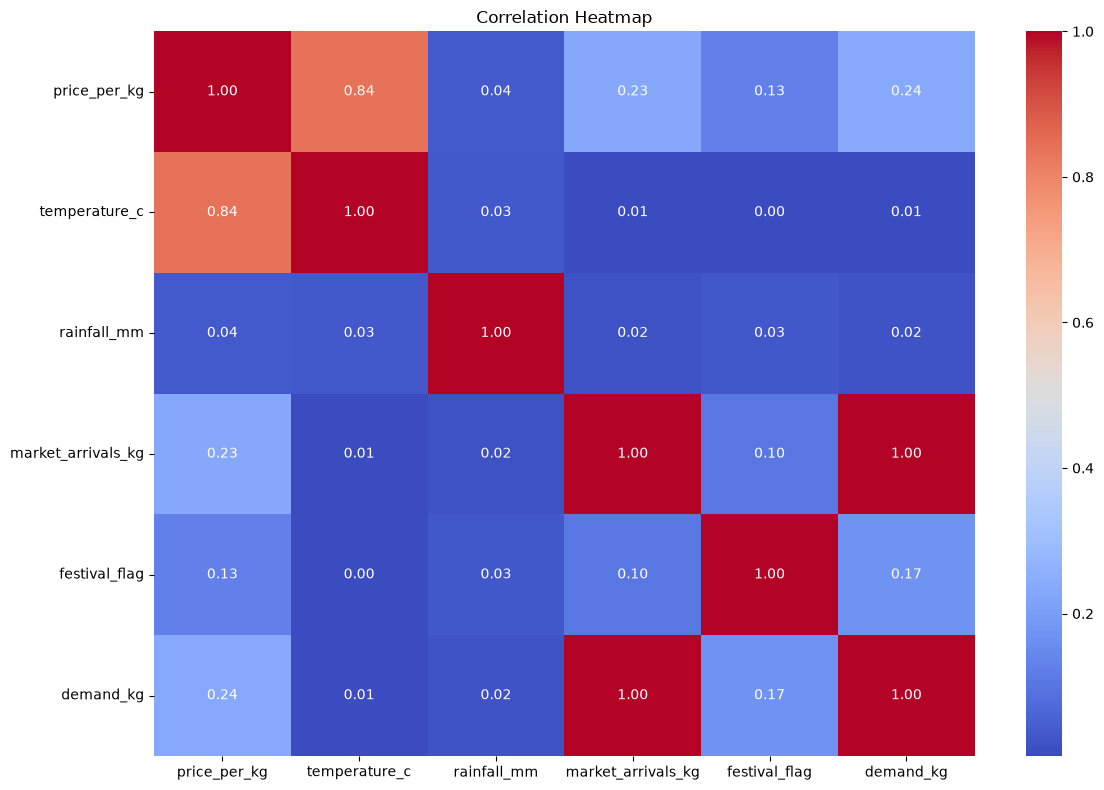

In [25]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

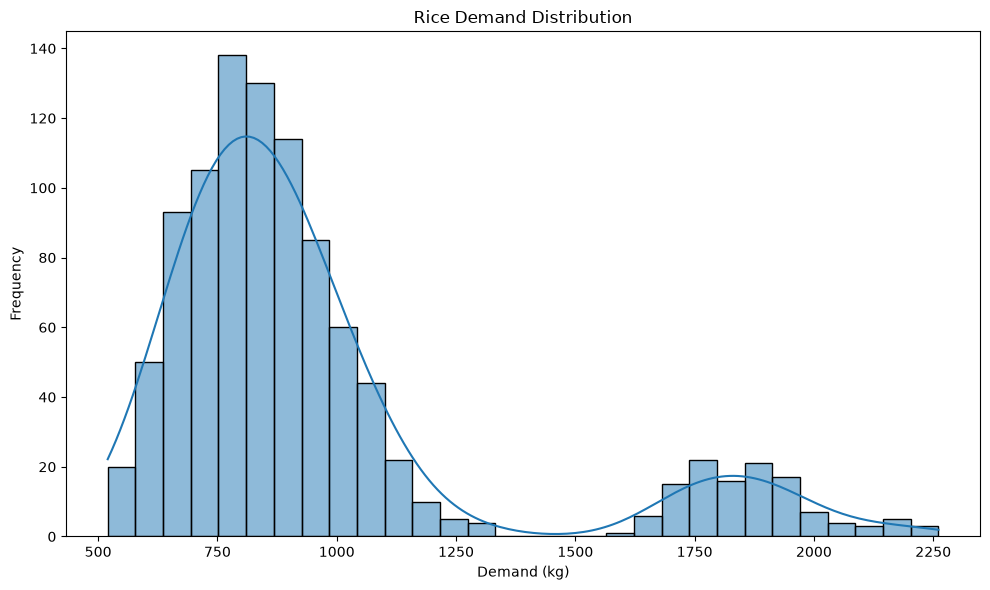

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["demand_kg"],
    bins=30,
    kde=True
)

plt.title("Rice Demand Distribution")

plt.xlabel("Demand (kg)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

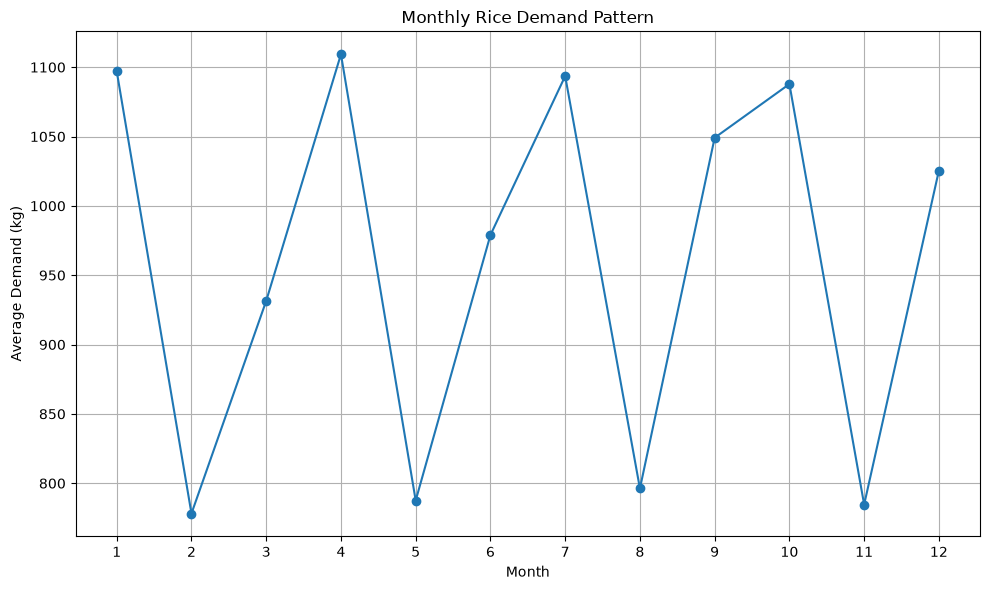

In [27]:
df["month_temp"] = df["date"].dt.month

monthly_demand = (
    df.groupby("month_temp")["demand_kg"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Monthly Rice Demand Pattern")

plt.xlabel("Month")

plt.ylabel("Average Demand (kg)")

plt.xticks(range(1, 13))

plt.grid()

plt.tight_layout()

plt.show()

df = df.drop(
    columns=["month_temp"]
)

In [28]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["day_of_year"] = df["date"].dt.dayofyear

df["week_of_year"] = (
    df["date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)

df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

display(
    df.head()
)

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend
0,2023-01-01,Delhi,Rice,42.3,16.8,0.0,2098,0,1609,2023,1,1,6,1,52,1,1
1,2023-01-02,Delhi,Rice,42.8,16.7,1.1,2160,0,1653,2023,1,2,0,2,1,1,0
2,2023-01-03,Delhi,Rice,42.5,16.5,0.6,2185,0,1679,2023,1,3,1,3,1,1,0
3,2023-01-04,Delhi,Rice,43.0,16.8,0.0,2231,0,1716,2023,1,4,2,4,1,1,0
4,2023-01-05,Delhi,Rice,43.4,16.9,0.8,2278,0,1758,2023,1,5,3,5,1,1,0


In [29]:
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

print("Cyclical features created.")

Cyclical features created.


In [30]:
lag_periods = [
    1,
    2,
    3,
    7,
    14,
    30
]

for lag in lag_periods:
    
    df[f"lag_{lag}"] = (
        df.groupby(
            ["location", "crop"]
        )["demand_kg"]
        .shift(lag)
    )

print("Lag features created.")

display(df.head(10))

Lag features created.


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg,year,...,month_sin,month_cos,day_of_week_sin,day_of_week_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30
0,2023-01-01,Delhi,Rice,42.3,16.8,0.0,2098,0,1609,2023,...,0.5,0.866025,-0.781831,0.623490,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,Delhi,Rice,42.8,16.7,1.1,2160,0,1653,2023,...,0.5,0.866025,0.000000,1.000000,1609.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,Delhi,Rice,42.5,16.5,0.6,2185,0,1679,2023,...,0.5,0.866025,0.781831,0.623490,1653.0,1609.0,NaN,NaN,NaN,NaN
3,2023-01-04,Delhi,Rice,43.0,16.8,0.0,2231,0,1716,2023,...,0.5,0.866025,0.974928,-0.222521,1679.0,1653.0,1609.0,NaN,NaN,NaN
4,2023-01-05,Delhi,Rice,43.4,16.9,0.8,2278,0,1758,2023,...,0.5,0.866025,0.433884,-0.900969,1716.0,1679.0,1653.0,NaN,NaN,NaN
5,2023-01-06,Delhi,Rice,43.6,16.6,0.4,2319,0,1777,2023,...,0.5,0.866025,-0.433884,-0.900969,1758.0,1716.0,1679.0,NaN,NaN,NaN
6,2023-01-07,Delhi,Rice,43.8,16.4,0.7,2389,0,1836,2023,...,0.5,0.866025,-0.974928,-0.222521,1777.0,1758.0,1716.0,NaN,NaN,NaN
7,2023-01-08,Delhi,Rice,43.7,16.3,0.0,2403,0,1864,2023,...,0.5,0.866025,-0.781831,0.623490,1836.0,1777.0,1758.0,1609.0,NaN,NaN
8,2023-01-09,Delhi,Rice,44.1,16.6,0.0,2470,0,1900,2023,...,0.5,0.866025,0.000000,1.000000,1864.0,1836.0,1777.0,1653.0,NaN,NaN
9,2023-01-10,Delhi,Rice,44.4,16.5,0.0,2502,1,2078,2023,...,0.5,0.866025,0.781831,0.623490,1900.0,1864.0,1836.0,1679.0,NaN,NaN


In [31]:
grouped_demand = (
    df.groupby(
        ["location", "crop"]
    )["demand_kg"]
)

df["rolling_mean_7"] = (
    grouped_demand
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

df["rolling_mean_14"] = (
    grouped_demand
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

df["rolling_mean_30"] = (
    grouped_demand
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

df["rolling_std_7"] = (
    grouped_demand
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

df["rolling_std_30"] = (
    grouped_demand
    .transform(
        lambda x: x.shift(1).rolling(30).std()
    )
)

print("Rolling features created without leakage.")

Rolling features created without leakage.


In [32]:
feature_nan_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

before_rows = len(df)

df_model = df.dropna(
    subset=feature_nan_columns
).copy()

after_rows = len(df_model)

print("Rows Before:", before_rows)

print("Rows After:", after_rows)

print(
    "Rows Removed:",
    before_rows - after_rows
)

Rows Before: 1000
Rows After: 730
Rows Removed: 270


In [33]:
target_column = "demand_kg"

categorical_features = [
    "location",
    "crop"
]

numerical_features = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",
    
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

feature_columns = (
    categorical_features +
    numerical_features
)

X = df_model[
    feature_columns
].copy()

y = df_model[
    target_column
].copy()

print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (730, 30)
y Shape: (730,)


In [34]:
df_model = (
    df_model
    .sort_values("date")
    .reset_index(drop=True)
)

X = df_model[
    feature_columns
].copy()

y = df_model[
    target_column
].copy()

print(
    df_model[
        ["date", "location", "crop"]
    ].head()
)

        date location  crop
0 2023-09-28    Delhi  Rice
1 2023-09-29    Delhi  Rice
2 2023-09-30    Delhi  Rice
3 2023-10-01    Delhi  Rice
4 2023-10-02    Delhi  Rice


In [35]:
total_rows = len(df_model)

train_end = int(
    total_rows * 0.70
)

validation_end = int(
    total_rows * 0.85
)

X_train = X.iloc[
    :train_end
].copy()

y_train = y.iloc[
    :train_end
].copy()

X_val = X.iloc[
    train_end:validation_end
].copy()

y_val = y.iloc[
    train_end:validation_end
].copy()

X_test = X.iloc[
    validation_end:
].copy()

y_test = y.iloc[
    validation_end:
].copy()

print("Train Size:", X_train.shape)

print("Validation Size:", X_val.shape)

print("Test Size:", X_test.shape)

print("\nTrain Date Range:")
print(
    df_model.iloc[:train_end]["date"].min(),
    "to",
    df_model.iloc[:train_end]["date"].max()
)

print("\nValidation Date Range:")
print(
    df_model.iloc[
        train_end:validation_end
    ]["date"].min(),
    "to",
    df_model.iloc[
        train_end:validation_end
    ]["date"].max()
)

print("\nTest Date Range:")
print(
    df_model.iloc[
        validation_end:
    ]["date"].min(),
    "to",
    df_model.iloc[
        validation_end:
    ]["date"].max()
)

Train Size: (510, 30)
Validation Size: (110, 30)
Test Size: (110, 30)

Train Date Range:
2023-09-28 00:00:00 to 2025-02-18 00:00:00

Validation Date Range:
2025-02-19 00:00:00 to 2025-06-08 00:00:00

Test Date Range:
2025-06-09 00:00:00 to 2025-09-26 00:00:00


In [36]:
numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created."
)

Preprocessing pipeline created.


In [37]:
def safe_mape(
    y_true,
    y_pred
):
    
    y_true = np.array(
        y_true
    )
    
    y_pred = np.array(
        y_pred
    )
    
    non_zero_mask = (
        y_true != 0
    )
    
    if non_zero_mask.sum() == 0:
        return np.nan
    
    return (
        np.mean(
            np.abs(
                (
                    y_true[non_zero_mask] -
                    y_pred[non_zero_mask]
                )
                /
                y_true[non_zero_mask]
            )
        )
        * 100
    )

In [38]:
def evaluate_model(
    y_true,
    y_pred
):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    mape = safe_mape(
        y_true,
        y_pred
    )
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [39]:
baseline_train_pred = (
    df_model.iloc[
        :train_end
    ]["lag_1"]
)

baseline_val_pred = (
    df_model.iloc[
        train_end:validation_end
    ]["lag_1"]
)

baseline_test_pred = (
    df_model.iloc[
        validation_end:
    ]["lag_1"]
)

baseline_train_metrics = evaluate_model(
    y_train,
    baseline_train_pred
)

baseline_val_metrics = evaluate_model(
    y_val,
    baseline_val_pred
)

baseline_test_metrics = evaluate_model(
    y_test,
    baseline_test_pred
)

print("Baseline Validation Metrics:")
print(baseline_val_metrics)

print("\nBaseline Test Metrics:")
print(baseline_test_metrics)

Baseline Validation Metrics:
{'MAE': 59.627272727272725, 'RMSE': np.float64(103.02740147429446), 'R2': 0.9044973305888683, 'MAPE': np.float64(6.61971287037328)}

Baseline Test Metrics:
{'MAE': 63.5, 'RMSE': np.float64(112.65341055241474), 'R2': 0.9310862412920062, 'MAPE': np.float64(6.3171580593109375)}


In [40]:
linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            LinearRegression()
        )
    ]
)

print(
    "Linear Regression pipeline created."
)

Linear Regression pipeline created.


In [41]:
linear_pipeline.fit(
    X_train,
    y_train
)

print(
    "Linear Regression trained successfully."
)

Linear Regression trained successfully.


In [42]:
linear_train_pred = (
    linear_pipeline.predict(
        X_train
    )
)

linear_val_pred = (
    linear_pipeline.predict(
        X_val
    )
)

linear_test_pred = (
    linear_pipeline.predict(
        X_test
    )
)

print(
    "Predictions generated."
)

Predictions generated.


In [43]:
linear_train_metrics = evaluate_model(
    y_train,
    linear_train_pred
)

linear_val_metrics = evaluate_model(
    y_val,
    linear_val_pred
)

linear_test_metrics = evaluate_model(
    y_test,
    linear_test_pred
)

print("Training Metrics:")
print(linear_train_metrics)

print("\nValidation Metrics:")
print(linear_val_metrics)

print("\nTest Metrics:")
print(linear_test_metrics)

Training Metrics:
{'MAE': 4.904667213062018, 'RMSE': np.float64(6.87530477059359), 'R2': 0.9996320166059403, 'MAPE': np.float64(0.5040565173212134)}

Validation Metrics:
{'MAE': 5.293926004751515, 'RMSE': np.float64(8.097214403081503), 'R2': 0.9994100960610995, 'MAPE': np.float64(0.5307306445287066)}

Test Metrics:
{'MAE': 6.750702635495385, 'RMSE': np.float64(10.694439839304229), 'R2': 0.9993789403237529, 'MAPE': np.float64(0.626247296060196)}


In [44]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            xgb_model
        )
    ]
)

print(
    "XGBoost pipeline created."
)

XGBoost pipeline created.


In [45]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print(
    "XGBoost trained successfully."
)

XGBoost trained successfully.


In [46]:
xgb_train_pred = (
    xgb_pipeline.predict(
        X_train
    )
)

xgb_val_pred = (
    xgb_pipeline.predict(
        X_val
    )
)

xgb_test_pred = (
    xgb_pipeline.predict(
        X_test
    )
)

print(
    "XGBoost predictions generated."
)

XGBoost predictions generated.


In [47]:
xgb_train_metrics = evaluate_model(
    y_train,
    xgb_train_pred
)

xgb_val_metrics = evaluate_model(
    y_val,
    xgb_val_pred
)

xgb_test_metrics = evaluate_model(
    y_test,
    xgb_test_pred
)

print("Training Metrics:")
print(xgb_train_metrics)

print("\nValidation Metrics:")
print(xgb_val_metrics)

print("\nTest Metrics:")
print(xgb_test_metrics)

Training Metrics:
{'MAE': 3.7078607082366943, 'RMSE': np.float64(5.000554435507685), 'R2': 0.9998053312301636, 'MAPE': np.float64(0.40775327442943876)}

Validation Metrics:
{'MAE': 7.837986946105957, 'RMSE': np.float64(11.572206783869394), 'R2': 0.9987951517105103, 'MAPE': np.float64(0.7719485117619125)}

Test Metrics:
{'MAE': 9.518792152404785, 'RMSE': np.float64(15.555822939315552), 'R2': 0.9986859560012817, 'MAPE': np.float64(0.8421076688116026)}


In [48]:
tscv = TimeSeriesSplit(
    n_splits=5
)

print(
    "TimeSeriesSplit created."
)

TimeSeriesSplit created.


In [49]:
linear_cv_results = []

for fold, (
    train_index,
    val_index
) in enumerate(
    tscv.split(X),
    start=1
):
    
    X_fold_train = X.iloc[
        train_index
    ]
    
    y_fold_train = y.iloc[
        train_index
    ]
    
    X_fold_val = X.iloc[
        val_index
    ]
    
    y_fold_val = y.iloc[
        val_index
    ]
    
    fold_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            
            (
                "model",
                LinearRegression()
            )
        ]
    )
    
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )
    
    fold_pred = (
        fold_model.predict(
            X_fold_val
        )
    )
    
    metrics = evaluate_model(
        y_fold_val,
        fold_pred
    )
    
    metrics["Fold"] = fold
    
    linear_cv_results.append(
        metrics
    )

linear_cv_df = pd.DataFrame(
    linear_cv_results
)

display(
    linear_cv_df
)

print(
    linear_cv_df.mean(
        numeric_only=True
    )
)

,MAE,RMSE,R2,MAPE,Fold
0,62.541741,75.486114,0.943686,7.445450,1
1,13.635881,16.309407,0.998152,1.492869,2
2,4.943618,7.386448,0.999559,0.479954,3
3,5.090688,7.687222,0.999434,0.521577,4
4,6.536262,9.927278,0.999424,0.620165,5


MAE     18.549638
RMSE    23.359294
R2       0.988051
MAPE     2.112003
Fold     3.000000
dtype: float64


In [50]:
xgb_cv_results = []

for fold, (
    train_index,
    val_index
) in enumerate(
    tscv.split(X),
    start=1
):
    
    X_fold_train = X.iloc[
        train_index
    ]
    
    y_fold_train = y.iloc[
        train_index
    ]
    
    X_fold_val = X.iloc[
        val_index
    ]
    
    y_fold_val = y.iloc[
        val_index
    ]
    
    fold_xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        n_jobs=-1
    )
    
    fold_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            
            (
                "model",
                fold_xgb_model
            )
        ]
    )
    
    fold_pipeline.fit(
        X_fold_train,
        y_fold_train
    )
    
    fold_pred = (
        fold_pipeline.predict(
            X_fold_val
        )
    )
    
    metrics = evaluate_model(
        y_fold_val,
        fold_pred
    )
    
    metrics["Fold"] = fold
    
    xgb_cv_results.append(
        metrics
    )

xgb_cv_df = pd.DataFrame(
    xgb_cv_results
)

display(
    xgb_cv_df
)

print(
    xgb_cv_df.mean(
        numeric_only=True
    )
)

,MAE,RMSE,R2,MAPE,Fold
0,10.254277,16.317801,0.997368,1.052282,1
1,8.393572,13.409431,0.998751,0.809437,2
2,13.477978,25.270373,0.994833,1.150016,3
3,7.750463,11.073560,0.998826,0.770737,4
4,10.084366,15.856596,0.998530,0.916362,5


MAE      9.992131
RMSE    16.385552
R2       0.997662
MAPE     0.939767
Fold     3.000000
dtype: float64


In [51]:
results = pd.DataFrame(
    [
        {
            "Model": "Baseline",
            "CV MAE": np.nan,
            "CV RMSE": np.nan,
            "CV R2": np.nan,
            "Test MAE": baseline_test_metrics["MAE"],
            "Test RMSE": baseline_test_metrics["RMSE"],
            "Test R2": baseline_test_metrics["R2"]
        },
        
        {
            "Model": "Linear Regression",
            "CV MAE": linear_cv_df["MAE"].mean(),
            "CV RMSE": linear_cv_df["RMSE"].mean(),
            "CV R2": linear_cv_df["R2"].mean(),
            "Test MAE": linear_test_metrics["MAE"],
            "Test RMSE": linear_test_metrics["RMSE"],
            "Test R2": linear_test_metrics["R2"]
        },
        
        {
            "Model": "XGBoost",
            "CV MAE": xgb_cv_df["MAE"].mean(),
            "CV RMSE": xgb_cv_df["RMSE"].mean(),
            "CV R2": xgb_cv_df["R2"].mean(),
            "Test MAE": xgb_test_metrics["MAE"],
            "Test RMSE": xgb_test_metrics["RMSE"],
            "Test R2": xgb_test_metrics["R2"]
        }
    ]
)

results = results.sort_values(
    by="Test RMSE"
)

display(
    results
)

,Model,CV MAE,CV RMSE,CV R2,Test MAE,Test RMSE,Test R2
1,Linear Regression,18.549638,23.359294,0.988051,6.750703,10.694440,0.999379
2,XGBoost,9.992131,16.385552,0.997662,9.518792,15.555823,0.998686
0,Baseline,NaN,NaN,NaN,63.500000,112.653411,0.931086


In [52]:
test_results = df_model.iloc[
    validation_end:
][
    [
        "date",
        "location",
        "crop"
    ]
].copy()

test_results["actual"] = (
    y_test.values
)

test_results["baseline_prediction"] = (
    baseline_test_pred.values
)

test_results["linear_prediction"] = (
    linear_test_pred
)

test_results["xgb_prediction"] = (
    xgb_test_pred
)

display(
    test_results.head()
)

,date,location,crop,actual,baseline_prediction,linear_prediction,xgb_prediction
620,2025-06-09,Rohtak,Rice,642,902.0,634.626130,635.256226
621,2025-06-10,Rohtak,Rice,669,642.0,662.061558,658.936462
622,2025-06-11,Rohtak,Rice,691,669.0,684.344737,682.663940
623,2025-06-12,Rohtak,Rice,716,691.0,711.235222,711.370605
624,2025-06-13,Rohtak,Rice,725,716.0,723.711373,721.607544


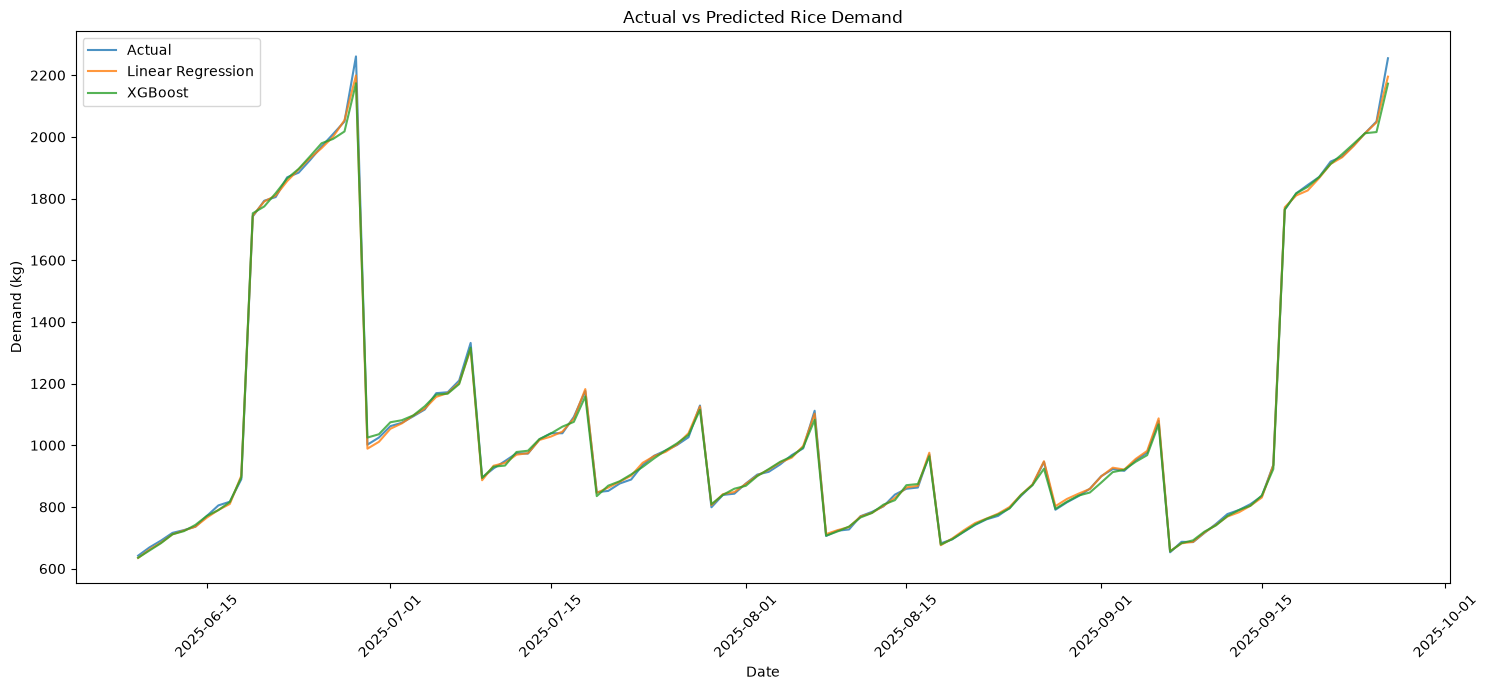

In [53]:
plt.figure(figsize=(15, 7))

plt.plot(
    test_results["date"],
    test_results["actual"],
    label="Actual",
    alpha=0.8
)

plt.plot(
    test_results["date"],
    test_results["linear_prediction"],
    label="Linear Regression",
    alpha=0.8
)

plt.plot(
    test_results["date"],
    test_results["xgb_prediction"],
    label="XGBoost",
    alpha=0.8
)

plt.title(
    "Actual vs Predicted Rice Demand"
)

plt.xlabel("Date")

plt.ylabel("Demand (kg)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


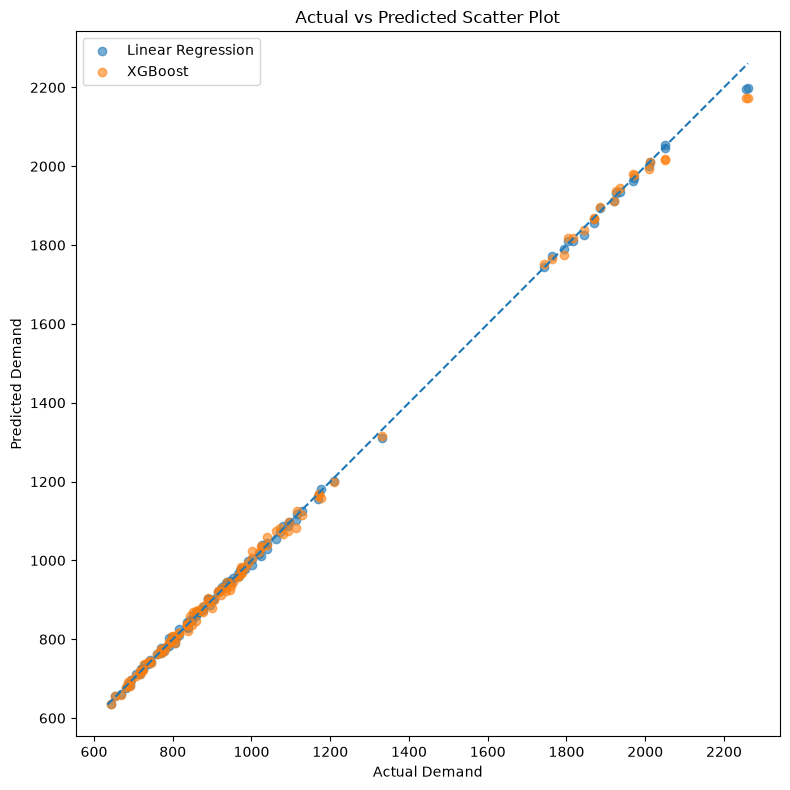

In [54]:
plt.figure(figsize=(8, 8))

plt.scatter(
    test_results["actual"],
    test_results["linear_prediction"],
    alpha=0.6,
    label="Linear Regression"
)

plt.scatter(
    test_results["actual"],
    test_results["xgb_prediction"],
    alpha=0.6,
    label="XGBoost"
)

minimum = min(
    test_results["actual"].min(),
    test_results["linear_prediction"].min(),
    test_results["xgb_prediction"].min()
)

maximum = max(
    test_results["actual"].max(),
    test_results["linear_prediction"].max(),
    test_results["xgb_prediction"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Demand"
)

plt.ylabel(
    "Predicted Demand"
)

plt.title(
    "Actual vs Predicted Scatter Plot"
)

plt.legend()

plt.tight_layout()

plt.show()

In [55]:
test_results["xgb_error"] = (
    test_results["actual"] -
    test_results["xgb_prediction"]
)

test_results["xgb_absolute_error"] = (
    np.abs(
        test_results["xgb_error"]
    )
)

test_results["xgb_percentage_error"] = (
    np.where(
        test_results["actual"] != 0,
        
        (
            test_results["xgb_absolute_error"]
            /
            test_results["actual"]
        )
        * 100,
        
        np.nan
    )
)

print(
    "Average Error:",
    test_results["xgb_error"].mean()
)

print(
    "Largest Absolute Error:",
    test_results["xgb_absolute_error"].max()
)

display(
    test_results
    .sort_values(
        "xgb_absolute_error",
        ascending=False
    )
    .head(10)
)

Average Error: 2.7798051313920453
Largest Absolute Error: 86.964111328125


,date,location,crop,actual,baseline_prediction,linear_prediction,xgb_prediction,xgb_error,xgb_absolute_error,xgb_percentage_error
639,2025-06-28,Delhi,Rice,2261,2050.0,2199.168345,2174.035889,86.964111,86.964111,3.846268
729,2025-09-26,Delhi,Rice,2255,2050.0,2195.346205,2172.683105,82.316895,82.316895,3.650417
728,2025-09-25,Delhi,Rice,2050,2012.0,2047.095218,2015.719727,34.280273,34.280273,1.672208
638,2025-06-27,Delhi,Rice,2050,2009.0,2054.109603,2017.663208,32.336792,32.336792,1.577404
679,2025-08-07,Faridabad,Rice,1112,990.0,1102.530600,1082.674194,29.325806,29.325806,2.637213
640,2025-06-29,Noida,Rice,1002,1314.0,988.993390,1024.999878,-22.999878,22.999878,2.295397
699,2025-08-27,Panipat,Rice,946,872.0,948.315000,923.809387,22.190613,22.190613,2.345731
657,2025-07-16,Ghaziabad,Rice,1039,1039.0,1044.321310,1060.332397,-21.332397,21.332397,2.053166
704,2025-09-01,Meerut,Rice,900,859.0,899.310005,879.284424,20.715576,20.715576,2.301731
631,2025-06-20,Delhi,Rice,1793,1742.0,1790.338564,1774.395752,18.604248,18.604248,1.037604


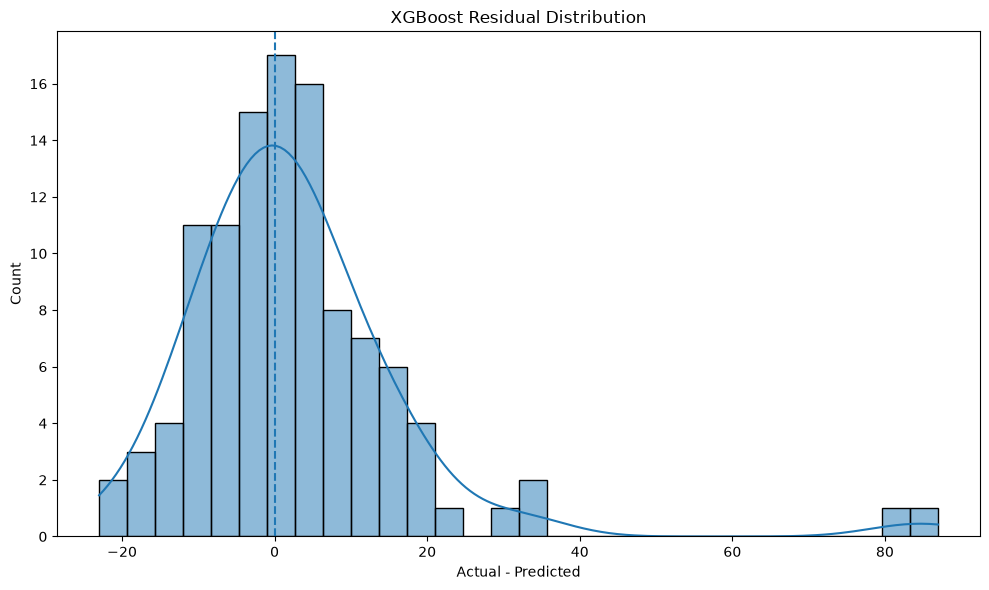

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(
    test_results["xgb_error"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "XGBoost Residual Distribution"
)

plt.xlabel(
    "Actual - Predicted"
)

plt.tight_layout()

plt.show()

In [57]:
overfitting_results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "XGBoost"
        ],
        
        "Train RMSE": [
            linear_train_metrics["RMSE"],
            xgb_train_metrics["RMSE"]
        ],
        
        "Validation RMSE": [
            linear_val_metrics["RMSE"],
            xgb_val_metrics["RMSE"]
        ],
        
        "Test RMSE": [
            linear_test_metrics["RMSE"],
            xgb_test_metrics["RMSE"]
        ]
    }
)

display(
    overfitting_results
)

,Model,Train RMSE,Validation RMSE,Test RMSE
0,Linear Regression,6.875305,8.097214,10.694440
1,XGBoost,5.000554,11.572207,15.555823


In [58]:
model_validation_results = {
    
    "Linear Regression": linear_val_metrics["RMSE"],
    
    "XGBoost": xgb_val_metrics["RMSE"]
}

best_model_name = min(
    model_validation_results,
    key=model_validation_results.get
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Validation RMSE:",
    model_validation_results[
        best_model_name
    ]
)

Best Model: Linear Regression
Validation RMSE: 8.097214403081503


In [59]:
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ]
)

y_train_final = pd.concat(
    [
        y_train,
        y_val
    ]
)

print(
    "Final Training Shape:",
    X_train_final.shape
)

Final Training Shape: (620, 30)


In [60]:
if best_model_name == "Linear Regression":
    
    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            
            (
                "model",
                LinearRegression()
            )
        ]
    )

else:
    
    final_xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        n_jobs=-1
    )
    
    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            
            (
                "model",
                final_xgb_model
            )
        ]
    )

final_model.fit(
    X_train_final,
    y_train_final
)

print(
    "Final model trained successfully!"
)

Final model trained successfully!


In [61]:
if best_model_name == "XGBoost":
    
    feature_names = (
        final_model
        .named_steps[
            "preprocessor"
        ]
        .get_feature_names_out()
    )
    
    importances = (
        final_model
        .named_steps[
            "model"
        ]
        .feature_importances_
    )
    
    feature_importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importances
        }
    )
    
    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )
    
    display(
        feature_importance_df
        .head(20)
    )

else:
    
    print(
        "XGBoost was not selected."
    )

XGBoost was not selected.


In [62]:
if best_model_name == "XGBoost":
    
    top_features = (
        feature_importance_df
        .head(20)
        .sort_values(
            "Importance"
        )
    )
    
    plt.figure(
        figsize=(10, 8)
    )
    
    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )
    
    plt.title(
        "Top 20 Feature Importances"
    )
    
    plt.xlabel(
        "Importance"
    )
    
    plt.tight_layout()
    
    plt.show()

In [63]:
MODEL_PATH = (
    "rice_demand_forecasting_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Model saved successfully!"
)

print(
    "Path:",
    MODEL_PATH
)

Model saved successfully!
Path: rice_demand_forecasting_model.joblib


In [64]:
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Model loaded successfully!"
)

print(
    type(loaded_model)
)

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [67]:
def create_future_features(
    historical_df,
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag
):
    
    future_date = pd.to_datetime(
        future_date
    )
    
    history = historical_df[
        (
            historical_df["location"]
            == location
        )
        &
        (
            historical_df["crop"]
            == crop
        )
        &
        (
            historical_df["date"]
            < future_date
        )
    ].copy()
    
    history = history.sort_values(
        "date"
    )
    
    if len(history) < 30:
        
        raise ValueError(
            "At least 30 historical observations are required."
        )
    
    future_row = {
        "location": location,
        "crop": crop,
        "price_per_kg": price_per_kg,
        "temperature_c": temperature_c,
        "rainfall_mm": rainfall_mm,
        "market_arrivals_kg": market_arrivals_kg,
        "festival_flag": festival_flag,
        
        "year": future_date.year,
        "month": future_date.month,
        "day": future_date.day,
        
        "day_of_week": (
            future_date.dayofweek
        ),
        
        "day_of_year": (
            future_date.dayofyear
        ),
        
        "week_of_year": int(
            future_date.isocalendar().week
        ),
        
        "quarter": future_date.quarter,
        
        "is_weekend": int(
            future_date.dayofweek >= 5
        )
    }
    
    future_row["month_sin"] = np.sin(
        2 * np.pi *
        future_row["month"] / 12
    )
    
    future_row["month_cos"] = np.cos(
        2 * np.pi *
        future_row["month"] / 12
    )
    
    future_row["day_of_week_sin"] = np.sin(
        2 * np.pi *
        future_row["day_of_week"] / 7
    )
    
    future_row["day_of_week_cos"] = np.cos(
        2 * np.pi *
        future_row["day_of_week"] / 7
    )
    
    demand_history = (
        history["demand_kg"]
        .values
    )
    
    future_row["lag_1"] = demand_history[-1]
    future_row["lag_2"] = demand_history[-2]
    future_row["lag_3"] = demand_history[-3]
    future_row["lag_7"] = demand_history[-7]
    future_row["lag_14"] = demand_history[-14]
    future_row["lag_30"] = demand_history[-30]
    
    future_row["rolling_mean_7"] = np.mean(
        demand_history[-7:]
    )
    
    future_row["rolling_mean_14"] = np.mean(
        demand_history[-14:]
    )
    
    future_row["rolling_mean_30"] = np.mean(
        demand_history[-30:]
    )
    
    future_row["rolling_std_7"] = np.std(
        demand_history[-7:],
        ddof=1
    )
    
    future_row["rolling_std_30"] = np.std(
        demand_history[-30:],
        ddof=1
    )
    
    future_df = pd.DataFrame(
        [future_row]
    )
    
    return future_df[
        feature_columns
    ]

In [77]:
## Cell 66 — Create Future Features


future_features = create_future_features(
    
    historical_df=df,
    
    location="Delhi",
    
    crop="Rice",
    
    future_date="2026-09-02",
    
    price_per_kg=40.0,
    
    temperature_c=28.0,
    
    rainfall_mm=2.0,
    
    market_arrivals_kg=1500.0,
    
    festival_flag=0
)

print("Future features created successfully!")
display(future_features)




## Cell 67 — Predict Future Demand

python
future_prediction = loaded_model.predict(
    future_features
)

predicted_demand = max(
    0,
    future_prediction[0]
)

print(
    "Predicted Rice Demand:",
    round(predicted_demand, 2),
    "kg"
)



Future features created successfully!


,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,year,month,day,...,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30
0,Delhi,Rice,40.0,28.0,2.0,1500.0,0,2026,9,2,...,2050,2012,1870,1969,1737,2002.142857,1980.642857,1932.8,126.370393,141.246031


NameError: name 'python' is not defined

In [68]:
future_prediction = (
    loaded_model.predict(
        future_features
    )
)

predicted_demand = max(
    0,
    future_prediction[0]
)

print(
    "Predicted Rice Demand:",
    round(
        predicted_demand,
        2
    ),
    "kg"
)

NameError: name 'future_features' is not defined

In [69]:
def predict_demand(
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag
):
    
    features = create_future_features(
        
        historical_df=df,
        
        location=location,
        
        crop=crop,
        
        future_date=future_date,
        
        price_per_kg=price_per_kg,
        
        temperature_c=temperature_c,
        
        rainfall_mm=rainfall_mm,
        
        market_arrivals_kg=market_arrivals_kg,
        
        festival_flag=festival_flag
    )
    
    prediction = (
        loaded_model.predict(
            features
        )[0]
    )
    
    return max(
        0,
        prediction
    )

In [70]:
locations = df[
    "location"
].unique()

future_date = "2026-09-02"

predictions = []

for location in locations:
    
    try:
        
        prediction = predict_demand(
            
            location=location,
            
            crop="Rice",
            
            future_date=future_date,
            
            price_per_kg=40.0,
            
            temperature_c=28.0,
            
            rainfall_mm=2.0,
            
            market_arrivals_kg=1500.0,
            
            festival_flag=0
        )
        
        predictions.append(
            {
                "location": location,
                "crop": "Rice",
                "predicted_demand_kg": prediction
            }
        )
    
    except Exception as e:
        
        print(
            f"Could not predict for {location}:",
            e
        )

prediction_df = pd.DataFrame(
    predictions
)

display(
    prediction_df
)

,location,crop,predicted_demand_kg
0,Delhi,Rice,1341.790526
1,Faridabad,Rice,1210.362690
2,Ghaziabad,Rice,1223.232258
3,Gurugram,Rice,1242.773333
4,Meerut,Rice,1203.522713
5,Noida,Rice,1243.105962
6,Panipat,Rice,1176.998321
7,Rohtak,Rice,1172.748363
8,Sonipat,Rice,1187.113264


In [ ]:
routing_df = prediction_df[
    prediction_df[
        "predicted_demand_kg"
    ] > 0
].copy()

routing_df = routing_df.sort_values(
    by="predicted_demand_kg",
    ascending=False
)

display(
    routing_df
)

In [ ]:
OUTPUT_PATH = (
    "predicted_rice_demand_for_routing.csv"
)

routing_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    "Routing file exported successfully!"
)

print(
    "File:",
    OUTPUT_PATH
)